In [1]:
from vivarium import Artifact, InteractiveContext
import pandas as pd, numpy as np, os

In [2]:
! pip list | grep vivarium

vivarium                  3.4.7
vivarium_build_utils      1.1.2
vivarium_cluster_tools    2.1.15
vivarium_gates_mncnh      0.1.dev166+ga33b147.d20250724 /mnt/share/homes/alibow/vivarium_gates_mncnh
vivarium_public_health    4.2.5
vivarium_testing_utils    0.2.3


In [3]:
! pip freeze | grep vivarium

vivarium==3.4.7
vivarium_build_utils==1.1.2
vivarium_cluster_tools==2.1.15
-e git+https://github.com/ihmeuw/vivarium_gates_mncnh.git@a33b147198c62503dc51e001f2f92cf70b640169#egg=vivarium_gates_mncnh
vivarium_public_health==4.2.5
vivarium_testing_utils==0.2.3


In [4]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from vivarium import InteractiveContext

In [5]:
from vivarium import Artifact 
artifact_dir = '/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model12.1.1/'
art = Artifact(artifact_dir + 'ethiopia.hdf', filter_terms=['age_start==0' and 'child_age_start == 0'])

In [6]:
[x for x in art.keys if 'relative_risk' in x]

['risk_factor.low_birth_weight_and_short_gestation.relative_risk',
 'risk_factor.low_birth_weight_and_short_gestation.relative_risk_interpolator',
 'intervention.no_cpap_risk.relative_risk',
 'intervention.no_antibiotics_risk.relative_risk',
 'intervention.no_probiotics_risk.relative_risk',
 'intervention.no_azithromycin_risk.relative_risk',
 'intervention.no_misoprostol_risk.relative_risk']

In [7]:
art.load('risk_factor.low_birth_weight_and_short_gestation.relative_risk').max()#.max()

draw_0      264.570867
draw_1      299.166842
draw_2      388.188397
draw_3      247.316405
draw_4      328.730501
               ...    
draw_495    284.249435
draw_496    231.411092
draw_497    353.591189
draw_498    273.888907
draw_499    347.538381
Length: 500, dtype: float64

In [8]:
from pathlib import Path

In [9]:
import vivarium_gates_mncnh
from vivarium.framework.configuration import build_model_specification

path = Path('/ihme/homes/alibow/vivarium_gates_mncnh/src/vivarium_gates_mncnh/model_specifications/model_spec.yaml')
custom_model_specification = build_model_specification(path)
del custom_model_specification.configuration.observers
# update artifact path manually
custom_model_specification.configuration.input_data.artifact_path = '/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model12.1.1/ethiopia.hdf'

In [10]:
custom_model_specification.configuration.input_data.artifact_path

'/mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model12.1.1/ethiopia.hdf'

In [11]:
draw = custom_model_specification.configuration.input_data.input_draw_number
draw = 'draw_' + str(draw)
draw

'draw_115'

In [12]:
sim = InteractiveContext(custom_model_specification)

2025-07-24 15:10:31.596 | INFO     | simulation_1-artifact_manager:78 - Running simulation from artifact located at /mnt/team/simulation_science/pub/models/vivarium_gates_mncnh/artifacts/model12.1.1/ethiopia.hdf.
2025-07-24 15:10:31.598 | INFO     | simulation_1-artifact_manager:79 - Artifact base filter terms are ['draw == 115'].
2025-07-24 15:10:31.600 | INFO     | simulation_1-artifact_manager:80 - Artifact additional filter terms are None.
2025-07-24 15:10:39.778 | WARNING  | simulation_1-results_manager:439 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']
2025-07-24 15:10:39.780 | WARNING  | simulation_1-results_manager:439 - Specified excluded stratifications are already not included by default: ['stillbirth', 'partial_term']
2025-07-24 15:10:40.025 | INFO     | simulation_1-results_manager:127 - The following stratifications are registered but not used by any observers: 
['sex']


In [13]:
pop = sim.get_population()
pop

,tracked,age,location,alive,exit_time,sex,entrance_time,ultrasound_type,successful_lbw_identification,attended_care_facility,...,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_all_causes_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_sepsis_and_other_neonatal_infections_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_sepsis_and_other_neonatal_infections_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_preterm_birth_with_rds_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_preterm_birth_with_rds_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_preterm_birth_without_rds_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_preterm_birth_without_rds_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma_relative_risk,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma_relative_risk
0,True,35.305676,Ethiopia,alive,NaT,Female,2024-12-31,no_ultrasound,False,False,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,True,40.980708,Ethiopia,alive,NaT,Female,2024-12-31,no_ultrasound,False,False,...,1.060454,1.318464,1.318464,1.060454,1.318464,1.060454,1.060454,1.318464,1.318464,1.060454
2,True,23.640954,Ethiopia,alive,NaT,Female,2024-12-31,no_ultrasound,False,False,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
3,True,17.785059,Ethiopia,alive,NaT,Female,2024-12-31,no_ultrasound,False,False,...,2.474172,3.622716,3.622716,2.474172,3.622716,2.474172,2.474172,3.622716,3.622716,2.474172
4,True,30.022872,Ethiopia,alive,NaT,Female,2024-12-31,no_ultrasound,False,False,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,True,33.124963,Ethiopia,alive,NaT,Female,2024-12-31,no_ultrasound,False,False,...,1.000000,1.221407,1.221407,1.000000,1.221407,1.000000,1.000000,1.221407,1.221407,1.000000
19996,True,18.245242,Ethiopia,alive,NaT,Female,2024-12-31,no_ultrasound,False,False,...,1.139495,1.648655,1.648655,1.139495,1.648655,1.139495,1.139495,1.648655,1.648655,1.139495
19997,True,37.770254,Ethiopia,alive,NaT,Female,2024-12-31,no_ultrasound,False,False,...,1.229451,1.856129,1.856129,1.229451,1.856129,1.229451,1.229451,1.856129,1.856129,1.229451
19998,True,20.122770,Ethiopia,alive,NaT,Female,2024-12-31,no_ultrasound,False,False,...,1.101477,1.363523,1.363523,1.101477,1.363523,1.101477,1.101477,1.363523,1.363523,1.101477


In [14]:
rr_cols = [x for x in pop.columns if 'effect_of_low' in x]

In [15]:
pop[rr_cols].max()
# great

effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk                                                  298.729130
effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_all_causes_relative_risk                                                   517.683172
effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_sepsis_and_other_neonatal_infections_relative_risk                517.683172
effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_sepsis_and_other_neonatal_infections_relative_risk               298.729130
effect_of_low_birth_weight_and_short_gestation_on_late_neonatal_neonatal_preterm_birth_with_rds_relative_risk                              517.683172
effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_preterm_birth_with_rds_relative_risk                             298.729130
effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_neonatal_preterm_birth_without_rds_

In [16]:
cols = ['pregnancy_outcome','child_alive','sex_of_child','child_age','birth_weight_exposure',
        'gestational_age_exposure','partial_term_pregnancy_duration',
       'effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk',
       'antibiotics_available', 'probiotics_available', 'cpap_available',
]

In [17]:
pop[cols]

,pregnancy_outcome,child_alive,sex_of_child,child_age,birth_weight_exposure,gestational_age_exposure,partial_term_pregnancy_duration,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk,antibiotics_available,probiotics_available,cpap_available
0,live_birth,alive,Male,0.000137,3637.920904,39.573905,NaN,1.000000,False,False,False
1,partial_term,dead,Male,0.000137,3382.823767,37.484357,21.931380,1.060454,False,False,False
2,partial_term,dead,Male,0.000137,4933.554215,39.170936,16.462451,1.000000,False,False,False
3,live_birth,alive,Male,0.000137,2566.835817,39.067176,NaN,2.474172,False,False,False
4,live_birth,alive,Male,0.000137,3943.019392,41.607772,NaN,1.000000,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
19995,live_birth,alive,Female,0.000137,3327.235805,39.799738,NaN,1.000000,False,False,False
19996,partial_term,dead,Male,0.000137,3075.612527,38.923508,20.069324,1.139495,False,False,False
19997,live_birth,alive,Female,0.000137,3107.835584,37.497404,NaN,1.229451,False,False,False
19998,live_birth,alive,Male,0.000137,3148.425451,39.939382,NaN,1.101477,False,False,False


In [18]:
[x for x in sim.list_values() if 'neonatal' in x and 'effect' not in x]

['lbwsg_paf_on_neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk.paf',
 'neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk.paf',
 'lbwsg_paf_on_neonatal_preterm_birth_with_rds.cause_specific_mortality_risk.paf',
 'neonatal_preterm_birth_with_rds.cause_specific_mortality_risk',
 'neonatal_preterm_birth_with_rds.cause_specific_mortality_risk.paf',
 'lbwsg_paf_on_neonatal_preterm_birth_without_rds.cause_specific_mortality_risk.paf',
 'neonatal_preterm_birth_without_rds.cause_specific_mortality_risk',
 'neonatal_preterm_birth_without_rds.cause_specific_mortality_risk.paf',
 'lbwsg_paf_on_neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk.paf',
 'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk',
 'neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk.paf'

In [19]:
[x for x in sim.list_values() if 'all_cause' in x]

['lbwsg_paf_on_all_causes.all_cause_mortality_risk.paf',
 'effect_of_low_birth_weight_and_short_gestation_on_all_causes.relative_risk',
 'all_causes.all_cause_mortality_risk',
 'all_causes.all_cause_mortality_risk.paf']

In [20]:
df = pd.concat([pop[cols],
                sim.get_value('all_causes.all_cause_mortality_risk')(pop.index).rename('intermediate_acmr'),
                sim.get_value('death_in_age_group_probability')(pop.index).rename('final_acmr'),
                sim.get_value('neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk')(pop.index).rename('intermediate_sepsis_csmr'),
                sim.get_value('neonatal_sepsis_and_other_neonatal_infections.csmr')(pop.index).rename('final_sepsis_csmr'),
                sim.get_value('neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.cause_specific_mortality_risk')(pop.index).rename('intermediate_enceph_csmr'),
                sim.get_value('neonatal_encephalopathy_due_to_birth_asphyxia_and_trauma.csmr')(pop.index).rename('final_enceph_csmr'),
                sim.get_value('neonatal_preterm_birth_without_rds.cause_specific_mortality_risk')(pop.index).rename('intermediate_preterm_without_rds_csmr'),
                sim.get_value('neonatal_preterm_birth_without_rds.csmr')(pop.index).rename('final_preterm_without_rds_csmr'),
                sim.get_value('neonatal_preterm_birth_with_rds.cause_specific_mortality_risk')(pop.index).rename('intermediate_preterm_with_rds_csmr'),
                sim.get_value('neonatal_preterm_birth_with_rds.csmr')(pop.index).rename('final_preterm_with_rds_csmr'),
                ], axis=1)
df = df.loc[df.pregnancy_outcome == 'live_birth'] # restrict to live births only
df

,pregnancy_outcome,child_alive,sex_of_child,child_age,birth_weight_exposure,gestational_age_exposure,partial_term_pregnancy_duration,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk,antibiotics_available,probiotics_available,...,intermediate_acmr,final_acmr,intermediate_sepsis_csmr,final_sepsis_csmr,intermediate_enceph_csmr,final_enceph_csmr,intermediate_preterm_without_rds_csmr,final_preterm_without_rds_csmr,intermediate_preterm_with_rds_csmr,final_preterm_with_rds_csmr
0,live_birth,alive,Male,0.000137,3637.920904,39.573905,NaN,1.000000,False,False,...,0.003923,0.003949,0.000408,0.000434,0.001422,0.001422,0.000000,0.000000,0.000000,0.000000
3,live_birth,alive,Male,0.000137,2566.835817,39.067176,NaN,2.474172,False,False,...,0.009705,0.009770,0.001010,0.001075,0.003519,0.003519,0.000000,0.000000,0.000000,0.000000
4,live_birth,alive,Male,0.000137,3943.019392,41.607772,NaN,1.000000,False,False,...,0.003923,0.003949,0.000408,0.000434,0.001422,0.001422,0.000000,0.000000,0.000000,0.000000
7,live_birth,alive,Male,0.000137,3031.661674,38.100551,NaN,1.201564,False,False,...,0.004713,0.004745,0.000491,0.000522,0.001709,0.001709,0.000000,0.000000,0.000000,0.000000
8,live_birth,alive,Male,0.000137,3021.271349,34.206911,NaN,9.379308,False,False,...,0.036792,0.037572,0.003829,0.004074,0.013339,0.013339,0.002211,0.002211,0.012531,0.013067
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,live_birth,alive,Male,0.000137,3471.738666,39.280593,NaN,1.000000,False,False,...,0.003923,0.003949,0.000408,0.000434,0.001422,0.001422,0.000000,0.000000,0.000000,0.000000
19995,live_birth,alive,Female,0.000137,3327.235805,39.799738,NaN,1.000000,False,False,...,0.002869,0.002887,0.000278,0.000296,0.001077,0.001077,0.000000,0.000000,0.000000,0.000000
19997,live_birth,alive,Female,0.000137,3107.835584,37.497404,NaN,1.229451,False,False,...,0.003528,0.003550,0.000342,0.000364,0.001324,0.001324,0.000000,0.000000,0.000000,0.000000
19998,live_birth,alive,Male,0.000137,3148.425451,39.939382,NaN,1.101477,False,False,...,0.004321,0.004349,0.000450,0.000478,0.001566,0.001566,0.000000,0.000000,0.000000,0.000000


In [22]:
sim.get_value('all_causes.all_cause_mortality_risk').mutators
# the intermediate ACMR is modified by LBWSG, but nothing else (not yet being modified by CSMRs/interventions)

[ValueModifier(resource_type='value_modifier', name='all_causes.all_cause_mortality_risk.1.risk_effect.low_birth_weight_and_short_gestation_on_cause.all_causes.all_cause_mortality_risk.adjust_target', component=LBWSGRiskEffect(target=cause.all_causes.all_cause_mortality_risk))]

In [23]:
# so let's check that intermediate ACMR varies with LBWSG exposure/RR

df['intermediate_acmr_without_rr'] = df.intermediate_acmr / df.effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk
df.groupby('sex_of_child').intermediate_acmr_without_rr.describe()

# okay, so there is no variation in this ACMR value when we divide by LBWSG RR, which means that it is not being modified by other things


,count,mean,std,min,25%,50%,75%,max
sex_of_child,,,,,,,,
Female,6508.0,0.002869,1.071211e-19,0.002869,0.002869,0.002869,0.002869,0.002869
Male,6639.0,0.003923,8.674271e-19,0.003923,0.003923,0.003923,0.003923,0.003923


In [24]:
# so let's compare the difference between the intermediate AMCR value in the sim and the artifact value
df.groupby('sex_of_child')['intermediate_acmr'].mean()

sex_of_child
Female    0.016463
Male      0.025306
Name: intermediate_acmr, dtype: float64

In [25]:
art.load('cause.all_causes.all_cause_mortality_risk')[[draw]]
# cool, we're pretty close

,,,,,draw_115
sex,age_start,age_end,year_start,year_end,
Female,0.000000,0.019178,2021,2022,0.016655
Male,0.000000,0.019178,2021,2022,0.025768
Female,0.019178,0.076712,2021,2022,0.004067
Male,0.019178,0.076712,2021,2022,0.006841


In [26]:
# okay, so let's try to do some V&V on LBWSG exposure

In [27]:
# load category info
cats = pd.DataFrame()
cats['cat'] = art.load('risk_factor.low_birth_weight_and_short_gestation.categories')
cats = cats.reset_index().rename(columns={'index':'parameter'})
cats['cat_ga'] = cats.cat.str.split("[", expand=True)[1]
cats['cat_bw'] = cats.cat.str.split("[", expand=True)[2]
cats['ga_min'] = cats.cat_ga.str.split(',', expand=True)[0]
cats['ga_max'] = cats.cat_ga.str.split(', ', expand=True)[1]#.astype(int)
cats['ga_max'] = cats.ga_max.str.split(' ',expand=True)[0].str.replace(")",'')
cats['ga_max'] = np.where(cats.ga_max.str.contains('42'), '42', cats.ga_max).astype(int)
cats['bw_min'] = cats.cat_bw.str.split(", ", expand=True)[0].str.replace('[', '')#.astype(int)
cats['bw_max'] = cats.cat_bw.str.split(', ', expand=True)[1]
cats['bw_max'] = cats.bw_max.str.replace(')','').str.replace('] g','').str.replace(' g','').astype(int)
cats = cats.drop(columns=['cat','cat_ga','cat_bw'])
cats.head()

,parameter,ga_min,ga_max,bw_min,bw_max
0,cat2,0,24,0,500
1,cat8,0,24,500,1000
2,cat10,24,26,500,1000
3,cat11,26,28,500,1000
4,cat14,30,32,500,1000


In [28]:
# load lbwsg category exposure data
art_lbwsg = art.load('risk_factor.low_birth_weight_and_short_gestation.birth_exposure')[[draw]].reset_index()
art_lbwsg = art_lbwsg.merge(cats, on='parameter')
art_lbwsg

,sex_of_child,year_start,year_end,parameter,draw_115,ga_min,ga_max,bw_min,bw_max
0,Female,2021,2022,cat10,0.000561,24,26,500,1000
1,Female,2021,2022,cat106,0.000773,36,37,1000,1500
2,Female,2021,2022,cat11,0.000480,26,28,500,1000
3,Female,2021,2022,cat116,0.004668,38,40,1000,1500
4,Female,2021,2022,cat117,0.010008,38,40,1500,2000
...,...,...,...,...,...,...,...,...,...
111,Male,2021,2022,cat88,0.006734,30,32,2500,3000
112,Male,2021,2022,cat89,0.001751,30,32,3000,3500
113,Male,2021,2022,cat90,0.000410,30,32,3500,4000
114,Male,2021,2022,cat95,0.005740,32,34,3000,3500


In [29]:
data = pop.loc[pop.pregnancy_outcome == 'live_birth'][['sex_of_child','child_age','child_alive','birth_weight_exposure','gestational_age_exposure']]
data

,sex_of_child,child_age,child_alive,birth_weight_exposure,gestational_age_exposure
0,Male,0.000137,alive,3637.920904,39.573905
3,Male,0.000137,alive,2566.835817,39.067176
4,Male,0.000137,alive,3943.019392,41.607772
7,Male,0.000137,alive,3031.661674,38.100551
8,Male,0.000137,alive,3021.271349,34.206911
...,...,...,...,...,...
19994,Male,0.000137,alive,3471.738666,39.280593
19995,Female,0.000137,alive,3327.235805,39.799738
19997,Female,0.000137,alive,3107.835584,37.497404
19998,Male,0.000137,alive,3148.425451,39.939382


In [30]:
# assign categorical exposures from continuous
params = pd.Series(np.nan, index=data.index, name='lbwsg_category')

for i in list(range(0, len(cats))):
    param = cats.loc[i]
    in_cat = ((data.gestational_age_exposure >= int(param.ga_min)) 
                 & (data.gestational_age_exposure < int(param.ga_max))
                 & (data.birth_weight_exposure >= int(param.bw_min))
                 & (data.birth_weight_exposure < int(param.bw_max)))
    params[in_cat] = param.parameter
    
params

0        cat54
3        cat44
4        cat55
7        cat52
8        cat39
         ...  
19994    cat52
19995    cat52
19997    cat48
19998    cat52
19999    cat24
Name: lbwsg_category, Length: 13147, dtype: object

In [31]:
data['parameter'] = params
prev = (pd.DataFrame(data.groupby('sex_of_child').parameter.value_counts(normalize=True))
        .rename(columns={'parameter':'prevalence'}).reset_index()
        .merge(art_lbwsg, on=['sex_of_child','parameter'], how = 'right')
)
prev

,sex_of_child,parameter,proportion,year_start,year_end,draw_115,ga_min,ga_max,bw_min,bw_max
0,Female,cat10,0.000461,2021,2022,0.000561,24,26,500,1000
1,Female,cat106,0.000307,2021,2022,0.000773,36,37,1000,1500
2,Female,cat11,0.000615,2021,2022,0.000480,26,28,500,1000
3,Female,cat116,0.004610,2021,2022,0.004668,38,40,1000,1500
4,Female,cat117,0.009219,2021,2022,0.010008,38,40,1500,2000
...,...,...,...,...,...,...,...,...,...,...
111,Male,cat88,0.004971,2021,2022,0.006734,30,32,2500,3000
112,Male,cat89,0.001356,2021,2022,0.001751,30,32,3000,3500
113,Male,cat90,0.000452,2021,2022,0.000410,30,32,3500,4000
114,Male,cat95,0.006326,2021,2022,0.005740,32,34,3000,3500


In [35]:
# calculate LBWSG category prevalence in sim
data['parameter'] = params
prev = (pd.DataFrame(data.groupby('sex_of_child').parameter.value_counts(normalize=True))
        .rename(columns={'parameter':'prevalence'}).reset_index()
        .merge(art_lbwsg, on=['sex_of_child','parameter'], how = 'right')
)
#prev = (pd.DataFrame(data.groupby('sex_of_child').parameter.value_counts(normalize=False))
#        .rename(columns={'parameter':'counts'}).reset_index()
#        .merge(prev, on=['sex_of_child','parameter'], how = 'right')
#)

assert np.all(prev.groupby('sex_of_child').proportion.sum() == 1), 'LBWSG exposure prevalence across categories does not sum to 1'
assert len(prev) == len(cats) * 2, 'some categories lost in merge'
prev['proportion'] = prev.proportion.fillna(0)
prev

,sex_of_child,parameter,proportion,year_start,year_end,draw_115,ga_min,ga_max,bw_min,bw_max
0,Female,cat10,0.000461,2021,2022,0.000561,24,26,500,1000
1,Female,cat106,0.000307,2021,2022,0.000773,36,37,1000,1500
2,Female,cat11,0.000615,2021,2022,0.000480,26,28,500,1000
3,Female,cat116,0.004610,2021,2022,0.004668,38,40,1000,1500
4,Female,cat117,0.009219,2021,2022,0.010008,38,40,1500,2000
...,...,...,...,...,...,...,...,...,...,...
111,Male,cat88,0.004971,2021,2022,0.006734,30,32,2500,3000
112,Male,cat89,0.001356,2021,2022,0.001751,30,32,3000,3500
113,Male,cat90,0.000452,2021,2022,0.000410,30,32,3500,4000
114,Male,cat95,0.006326,2021,2022,0.005740,32,34,3000,3500


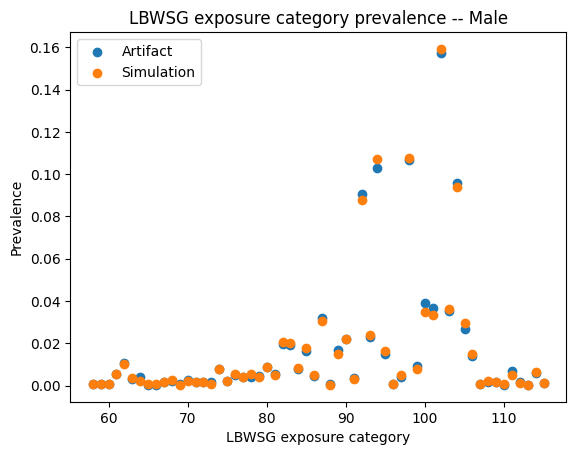

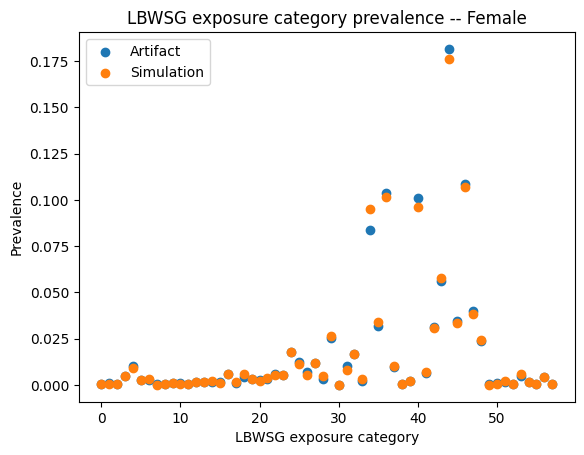

In [36]:
import matplotlib.pyplot as plt
for sex in ['Male','Female']:
    plt.figure()
    plt.scatter(prev.loc[prev.sex_of_child==sex].index, prev.loc[prev.sex_of_child==sex][draw], label='Artifact')
    plt.scatter(prev.loc[prev.sex_of_child==sex].index, prev.loc[prev.sex_of_child==sex].proportion, label='Simulation')
    plt.legend()
    plt.title(f'LBWSG exposure category prevalence -- {sex}')
    plt.xlabel('LBWSG exposure category')
    plt.ylabel('Prevalence')

# okay, so exposure in the sim looks pretty good... I don't think this is why we are off so much

In [37]:
# so now can we check the RRs are as we expect?
data['lbwsg_rr_pipeline'] = sim.get_value('effect_of_low_birth_weight_and_short_gestation_on_all_causes.relative_risk')(data.index)
data['lbwsg_rr_state_table'] = pop.effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk
assert np.all(data.lbwsg_rr_pipeline == data.lbwsg_rr_state_table), 'LBWSG RR in pipeline does not match state table'
data['lbwsg_paf_pipeline'] = sim.get_value('lbwsg_paf_on_all_causes.all_cause_mortality_risk.paf')(data.index) # okay, these are the same as the artifact

data

,sex_of_child,child_age,child_alive,birth_weight_exposure,gestational_age_exposure,parameter,lbwsg_rr_pipeline,lbwsg_rr_state_table,lbwsg_paf_pipeline
0,Male,0.000137,alive,3637.920904,39.573905,cat54,1.000000,1.000000,0.847770
3,Male,0.000137,alive,2566.835817,39.067176,cat44,2.474172,2.474172,0.847770
4,Male,0.000137,alive,3943.019392,41.607772,cat55,1.000000,1.000000,0.847770
7,Male,0.000137,alive,3031.661674,38.100551,cat52,1.201564,1.201564,0.847770
8,Male,0.000137,alive,3021.271349,34.206911,cat39,9.379308,9.379308,0.847770
...,...,...,...,...,...,...,...,...,...
19994,Male,0.000137,alive,3471.738666,39.280593,cat52,1.000000,1.000000,0.847770
19995,Female,0.000137,alive,3327.235805,39.799738,cat52,1.000000,1.000000,0.827718
19997,Female,0.000137,alive,3107.835584,37.497404,cat48,1.229451,1.229451,0.827718
19998,Male,0.000137,alive,3148.425451,39.939382,cat52,1.101477,1.101477,0.847770


In [38]:
from vivarium_public_health.risks.implementations.low_birth_weight_and_short_gestation import (
    LBWSGRisk as LBWSGRisk_,
)
from vivarium_public_health.risks.implementations.low_birth_weight_and_short_gestation import (
    LBWSGRiskEffect as LBWSGRiskEffect_,
)

In [39]:
import pickle

In [40]:
interpolators = art.load('risk_factor.low_birth_weight_and_short_gestation.relative_risk_interpolator')[draw].reset_index()
interpolators = (interpolators[interpolators['child_age_start'] == 0]
                 .drop(columns=['child_age_start','child_age_end','year_start','year_end'])
                 .set_index(['sex_of_child'])                
).reset_index()
interpolators['age_group_id'] = 2
interpolators = interpolators.set_index(['sex_of_child','age_group_id'])[draw]
interpolators = interpolators.apply(lambda x: pickle.loads(bytes.fromhex(x)))
interpolators


sex_of_child  age_group_id
Female        2               <scipy.interpolate._fitpack2.RectBivariateSpli...
Male          2               <scipy.interpolate._fitpack2.RectBivariateSpli...
Name: draw_115, dtype: object

In [41]:
from vivarium_gates_mncnh.constants import data_keys, metadata

In [42]:
# inputs for interpolator function

is_male = data.sex_of_child == 'Male'
gestational_age = data.gestational_age_exposure
birth_weight = data.birth_weight_exposure

In [43]:
log_relative_risk = pd.Series(0.0, index=data.index, name='interpolated_rr')
log_relative_risk[is_male] = (interpolators['Male', 2](gestational_age[is_male],
                                                       birth_weight[is_male],
                                                       grid=False))
log_relative_risk[~is_male] = (interpolators['Female', 2](gestational_age[~is_male],
                                                          birth_weight[~is_male],
                                                          grid=False))
relative_risk = np.exp(log_relative_risk)
relative_risk

0         1.000000
3         2.474172
4         1.000000
7         1.201564
8         9.379308
           ...    
19994     1.000000
19995     1.000000
19997     1.229451
19998     1.101477
19999    26.291656
Name: interpolated_rr, Length: 13147, dtype: float64

In [44]:
data['interpolated_rr'] = relative_risk
data

,sex_of_child,child_age,child_alive,birth_weight_exposure,gestational_age_exposure,parameter,lbwsg_rr_pipeline,lbwsg_rr_state_table,lbwsg_paf_pipeline,interpolated_rr
0,Male,0.000137,alive,3637.920904,39.573905,cat54,1.000000,1.000000,0.847770,1.000000
3,Male,0.000137,alive,2566.835817,39.067176,cat44,2.474172,2.474172,0.847770,2.474172
4,Male,0.000137,alive,3943.019392,41.607772,cat55,1.000000,1.000000,0.847770,1.000000
7,Male,0.000137,alive,3031.661674,38.100551,cat52,1.201564,1.201564,0.847770,1.201564
8,Male,0.000137,alive,3021.271349,34.206911,cat39,9.379308,9.379308,0.847770,9.379308
...,...,...,...,...,...,...,...,...,...,...
19994,Male,0.000137,alive,3471.738666,39.280593,cat52,1.000000,1.000000,0.847770,1.000000
19995,Female,0.000137,alive,3327.235805,39.799738,cat52,1.000000,1.000000,0.827718,1.000000
19997,Female,0.000137,alive,3107.835584,37.497404,cat48,1.229451,1.229451,0.827718,1.229451
19998,Male,0.000137,alive,3148.425451,39.939382,cat52,1.101477,1.101477,0.847770,1.101477


In [45]:
data.interpolated_rr.max()

298.7291304913619

In [46]:
data['diff'] = data.lbwsg_rr_pipeline / data.interpolated_rr
data.loc[data['diff'] != 1].parameter.value_counts()
# hmm, differences for two categories...

parameter
cat54    671
cat53    233
Name: count, dtype: int64

In [47]:
cats.loc[cats.parameter.isin(['cat54','cat53'])]
# these are the TMREL categories! 

,parameter,ga_min,ga_max,bw_min,bw_max
41,cat53,38,40,4000,9999
42,cat54,38,40,3500,4000


In [48]:
data.loc[data['diff'] != 1]
# this makes sense, we are overwriting the interpolated RR with 1 because they are in the TMREL category which should be definitionally true. Ok

,sex_of_child,child_age,child_alive,birth_weight_exposure,gestational_age_exposure,parameter,lbwsg_rr_pipeline,lbwsg_rr_state_table,lbwsg_paf_pipeline,interpolated_rr,diff
82,Female,0.000137,alive,3822.998946,38.616485,cat54,1.0,1.0,0.827718,1.041072,0.960549
88,Male,0.000137,alive,3695.296230,38.351720,cat54,1.0,1.0,0.847770,1.070471,0.934169
90,Female,0.000137,alive,3578.479129,38.374482,cat54,1.0,1.0,0.827718,1.064412,0.939486
92,Female,0.000137,alive,3748.305869,38.724878,cat54,1.0,1.0,0.827718,1.029281,0.971552
110,Male,0.000137,alive,3510.471004,38.729255,cat54,1.0,1.0,0.847770,1.016775,0.983502
...,...,...,...,...,...,...,...,...,...,...,...
19939,Female,0.000137,alive,3960.229227,38.294359,cat54,1.0,1.0,0.827718,1.076870,0.928617
19966,Female,0.000137,alive,3880.646652,38.471069,cat54,1.0,1.0,0.827718,1.057082,0.946000
19972,Male,0.000137,alive,4439.447613,38.933280,cat53,1.0,1.0,0.847770,1.007901,0.992161
19983,Male,0.000137,alive,3782.540146,38.355543,cat54,1.0,1.0,0.847770,1.078977,0.926804


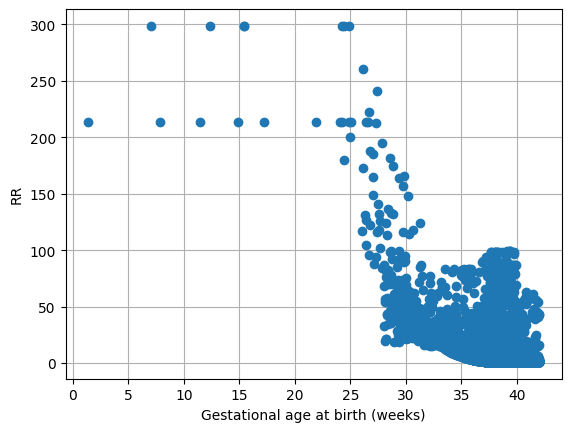

In [49]:
plt.plot(data.gestational_age_exposure, data.interpolated_rr, 'o', label='interpolated RR')
plt.xlabel('Gestational age at birth (weeks)')
plt.ylabel('RR')
plt.grid()

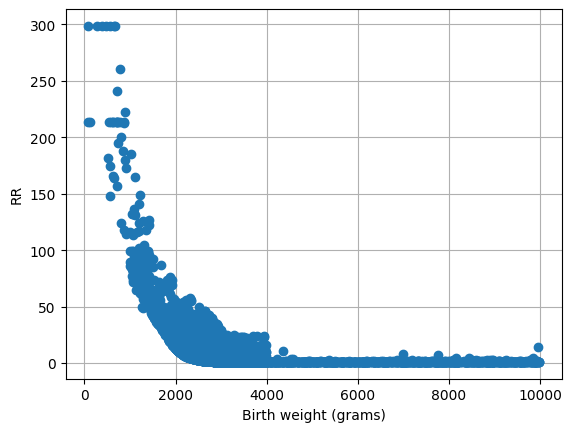

In [50]:
plt.plot(data.birth_weight_exposure, data.interpolated_rr, 'o', label='interpolated RR')
plt.xlabel('Birth weight (grams)')
plt.ylabel('RR')
plt.grid()

In [51]:
# great, we checked that ACMRisk varies with assigned LBWSG RR values 
# and we checked that the LBWSG RR values are as expected


In [52]:
# so let's take some steps and see if all of this is maintained

In [53]:
sim.step() # pregnancy
sim.step() # delivery facility
sim.step() # azithromycin
sim.step() # misoprostol
sim.step() # cpap
sim.step() # antibiotics
sim.step() # probiotics
sim.step() # maternal obstructed labor
sim.step() # maternal hemorrhage
sim.step() # maternal sepsis
sim.step() # maternal mortality
sim.step() # ENN mortality

In [54]:
stepped_pop = sim.get_population()

In [55]:
sim.list_values()

['simulant_step_size',
 'risk_factor.hemoglobin.exposure_parameters',
 'hemoglobin.propensity',
 'hemoglobin.exposure',
 'birth_outcome_probabilities',
 'pregnancy_duration',
 'maternal_obstructed_labor_and_uterine_rupture.incidence_risk',
 'maternal_hemorrhage.incidence_risk',
 'maternal_sepsis_and_other_maternal_infections.incidence_risk',
 'risk_factor.low_birth_weight_and_short_gestation.exposure_parameters',
 'birth_weight.birth_exposure',
 'gestational_age.birth_exposure',
 'lbwsg_paf_on_all_causes.all_cause_mortality_risk.paf',
 'effect_of_low_birth_weight_and_short_gestation_on_all_causes.relative_risk',
 'all_causes.all_cause_mortality_risk',
 'all_causes.all_cause_mortality_risk.paf',
 'lbwsg_paf_on_neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk.paf',
 'effect_of_low_birth_weight_and_short_gestation_on_neonatal_sepsis_and_other_neonatal_infections.relative_risk',
 'neonatal_sepsis_and_other_neonatal_infections.cause_specific_mortality_risk',
 'neo

In [57]:
stepped_data = stepped_pop.loc[stepped_pop.pregnancy_outcome=='live_birth'][cols]

# so now can we check the RRs are as we expect?
stepped_data['lbwsg_rr_pipeline'] = sim.get_value('effect_of_low_birth_weight_and_short_gestation_on_all_causes.relative_risk')(stepped_data.index)
stepped_data['lbwsg_rr_state_table'] = stepped_data.effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk
assert np.all(data.lbwsg_rr_pipeline == data.lbwsg_rr_state_table), 'LBWSG RR in pipeline does not match state table'
stepped_data['lbwsg_paf_pipeline'] = sim.get_value('lbwsg_paf_on_all_causes.all_cause_mortality_risk.paf')(stepped_data.index) # okay, these are the same as the artifact

stepped_data

,pregnancy_outcome,child_alive,sex_of_child,child_age,birth_weight_exposure,gestational_age_exposure,partial_term_pregnancy_duration,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk,antibiotics_available,probiotics_available,cpap_available,lbwsg_rr_pipeline,lbwsg_rr_state_table,lbwsg_paf_pipeline
0,live_birth,alive,Male,0.009589,3637.920904,39.573905,NaN,1.000000,False,False,False,1.000000,1.000000,0.847770
3,live_birth,alive,Male,0.009589,2566.835817,39.067176,NaN,2.474172,False,False,False,2.474172,2.474172,0.847770
4,live_birth,alive,Male,0.009589,3943.019392,41.607772,NaN,1.000000,True,False,False,1.000000,1.000000,0.847770
7,live_birth,alive,Male,0.009589,3031.661674,38.100551,NaN,1.201564,False,False,False,1.201564,1.201564,0.847770
8,live_birth,alive,Male,0.009589,3021.271349,34.206911,NaN,9.379308,True,False,False,9.379308,9.379308,0.847770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,live_birth,alive,Male,0.009589,3471.738666,39.280593,NaN,1.000000,False,False,False,1.000000,1.000000,0.847770
19995,live_birth,alive,Female,0.009589,3327.235805,39.799738,NaN,1.000000,True,False,False,1.000000,1.000000,0.827718
19997,live_birth,alive,Female,0.009589,3107.835584,37.497404,NaN,1.229451,False,False,False,1.229451,1.229451,0.827718
19998,live_birth,alive,Male,0.009589,3148.425451,39.939382,NaN,1.101477,True,False,False,1.101477,1.101477,0.847770


In [58]:
assert np.all(stepped_data.gestational_age_exposure == data.gestational_age_exposure)
assert np.all(stepped_data.birth_weight_exposure == data.birth_weight_exposure)
assert np.all(stepped_data.lbwsg_rr_pipeline == data.lbwsg_rr_pipeline)
assert np.all(stepped_data.lbwsg_rr_state_table == data.lbwsg_rr_state_table)
#assert np.all(stepped_data.lbwsg_paf_pipeline == data.lbwsg_paf_pipeline)
assert np.all(stepped_data.lbwsg_rr_pipeline == stepped_data.lbwsg_rr_state_table), 'LBWSG RR in pipeline does not match state table'

# so looks like taking steps is not messing up anything that we've already checked


In [59]:
# for good measure let's see what happens when we transition to the LNN age group
sim.step()
last_pop = sim.get_population()

In [60]:
last_data = last_pop.loc[last_pop.pregnancy_outcome == 'live_birth'][cols]
# so now can we check the RRs are as we expect?
last_data['lbwsg_rr_pipeline'] = sim.get_value('effect_of_low_birth_weight_and_short_gestation_on_all_causes.relative_risk')(last_data.index)
last_data['lbwsg_paf_pipeline'] = sim.get_value('lbwsg_paf_on_all_causes.all_cause_mortality_risk.paf')(last_data.index) # okay, these are the same as the artifact
last_data

# okay, pipeline values have appropriately updated to the lateneonatal age group values for this timestep


,pregnancy_outcome,child_alive,sex_of_child,child_age,birth_weight_exposure,gestational_age_exposure,partial_term_pregnancy_duration,effect_of_low_birth_weight_and_short_gestation_on_early_neonatal_all_causes_relative_risk,antibiotics_available,probiotics_available,cpap_available,lbwsg_rr_pipeline,lbwsg_paf_pipeline
0,live_birth,alive,Male,0.047945,3637.920904,39.573905,NaN,1.000000,False,False,False,1.000000,0.747811
3,live_birth,alive,Male,0.047945,2566.835817,39.067176,NaN,2.474172,False,False,False,3.622716,0.747811
4,live_birth,alive,Male,0.047945,3943.019392,41.607772,NaN,1.000000,True,False,False,1.000000,0.747811
7,live_birth,alive,Male,0.047945,3031.661674,38.100551,NaN,1.201564,False,False,False,1.749489,0.747811
8,live_birth,alive,Male,0.047945,3021.271349,34.206911,NaN,9.379308,True,False,False,4.620295,0.747811
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,live_birth,alive,Male,0.047945,3471.738666,39.280593,NaN,1.000000,False,False,False,1.136986,0.747811
19995,live_birth,alive,Female,0.047945,3327.235805,39.799738,NaN,1.000000,True,False,False,1.221407,0.749639
19997,live_birth,alive,Female,0.047945,3107.835584,37.497404,NaN,1.229451,False,False,False,1.856129,0.749639
19998,live_birth,alive,Male,0.047945,3148.425451,39.939382,NaN,1.101477,True,False,False,1.363523,0.747811
